In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


In [3]:
import os
import pandas as pd

# ۱. تعریف مسیر پوشه پروژه در درایو
WORK_DIR = '/content/drive/MyDrive/PreCalibration_Project'
os.makedirs(WORK_DIR, exist_ok=True)

# ۲. ساخت داده‌های نمونه
raw_data = {
    "sensor_id": [101, 102, 103, 104, 105, 106, 107, 108],
    "temperature": [22.4, 23.1, None, 22.8, 185.0, 22.1, 23.0, 22.5],  # 185.0 انحراف شدید دماست
    "voltage": [5.0, 4.9, 5.1, 5.0, 4.8, 5.0, 14.2, 5.1],              # 14.2 ولتاژ غیرمجاز است
    "status": ["OK", "OK", "OK", "FAIL", "OK", "OK", "OK", "OK"]
}

df_raw = pd.DataFrame(raw_data)
raw_file_path = os.path.join(WORK_DIR, 'raw_sensor_data.csv')
df_raw.to_csv(raw_file_path, index=False)

print(f"فایل داده‌های خام در پوشه پروژه ذخیره شد:\n{raw_file_path}")
display(df_raw)

فایل داده‌های خام در پوشه پروژه ذخیره شد:
/content/drive/MyDrive/PreCalibration_Project/raw_sensor_data.csv


,sensor_id,temperature,voltage,status
0,101,22.4,5.0,OK
1,102,23.1,4.9,OK
2,103,NaN,5.1,OK
3,104,22.8,5.0,FAIL
4,105,185.0,4.8,OK
5,106,22.1,5.0,OK
6,107,23.0,14.2,OK
7,108,22.5,5.1,OK


In [4]:
import numpy as np
import json
from datetime import datetime

class PreCalibrationValidator:
    def __init__(self, expected_schema: dict, z_score_threshold: float = 3.0):
        self.schema = expected_schema
        self.threshold = z_score_threshold
        self.report = {
            "timestamp": str(datetime.now()),
            "total_records": 0,
            "passed_records": 0,
            "failed_records": 0,
            "issues": []
        }

    def validate_schema(self, df: pd.DataFrame) -> bool:
        missing_cols = set(self.schema.keys()) - set(df.columns)
        if missing_cols:
            self.report["issues"].append(f"CRITICAL: Missing columns: {list(missing_cols)}")
            return False
        return True

    def detect_outliers_zscore(self, df: pd.DataFrame, column: str) -> pd.Series:
        if not pd.api.types.is_numeric_dtype(df[column]):
            return pd.Series([False] * len(df))

        mean = df[column].mean()
        std = df[column].std()
        if std == 0 or pd.isna(std):
            return pd.Series([False] * len(df))

        z_scores = (df[column] - mean) / std
        return np.abs(z_scores) > self.threshold

    def process(self, df: pd.DataFrame) -> pd.DataFrame:
        self.report["total_records"] = len(df)

        if not self.validate_schema(df):
            raise ValueError("Schema validation failed.")

        # بررسی مقادیر خالی
        null_mask = df.isnull().any(axis=1)
        null_count = int(null_mask.sum())
        if null_count > 0:
            self.report["issues"].append(f"Found {null_count} rows with missing values.")

        # بررسی انحرافات آماری (Outliers)
        outlier_mask = pd.Series([False] * len(df))
        for col in self.schema.keys():
            if pd.api.types.is_numeric_dtype(df[col]):
                col_outliers = self.detect_outliers_zscore(df, col)
                outlier_count = int(col_outliers.sum())
                if outlier_count > 0:
                    self.report["issues"].append(f"Found {outlier_count} statistical outliers in column '{col}'.")
                outlier_mask = outlier_mask | col_outliers

        # جداسازی داده‌های معتبر
        invalid_mask = null_mask | outlier_mask
        clean_df = df[~invalid_mask].copy()

        self.report["passed_records"] = len(clean_df)
        self.report["failed_records"] = int(invalid_mask.sum())
        return clean_df

    def export_report(self, file_path: str):
        with open(file_path, "w", encoding="utf-8") as f:
            json.dump(self.report, f, indent=4, ensure_ascii=False)
        print(f"گزارش درایو ذخیره شد: {file_path}")

print("✅ کلاس PreCalibrationValidator با موفقیت تعریف شد.")

✅ کلاس PreCalibrationValidator با موفقیت تعریف شد.


In [5]:
# ساختار مورد انتظار داده‌ها
schema = {
    "sensor_id": "int64",
    "temperature": "float64",
    "voltage": "float64",
    "status": "object"
}

# خواندن فایل خام از درایو
df_to_validate = pd.read_csv(raw_file_path)

# اجرای ولیدیشن با آستانه Z=2.0
validator = PreCalibrationValidator(expected_schema=schema, z_score_threshold=2.0)
clean_df = validator.process(df_to_validate)

# ذخیره خروجی‌ها در گوگل درایو
clean_file_path = os.path.join(WORK_DIR, 'clean_sensor_data.csv')
report_file_path = os.path.join(WORK_DIR, 'validation_report.json')

clean_df.to_csv(clean_file_path, index=False)
validator.export_report(report_file_path)

print("\n--- نتیجه: داده‌های پاک‌سازی‌شده برای کالیبراسیون ---")
display(clean_df)

گزارش درایو ذخیره شد: /content/drive/MyDrive/PreCalibration_Project/validation_report.json

--- نتیجه: داده‌های پاک‌سازی‌شده برای کالیبراسیون ---


,sensor_id,temperature,voltage,status
0,101,22.4,5.0,OK
1,102,23.1,4.9,OK
3,104,22.8,5.0,FAIL
5,106,22.1,5.0,OK
7,108,22.5,5.1,OK


In [6]:
with open(report_file_path, 'r', encoding='utf-8') as f:
    report_data = json.load(f)

print(json.dumps(report_data, indent=4, ensure_ascii=False))

{
    "timestamp": "2026-09-13 08:47:47.045955",
    "total_records": 8,
    "passed_records": 5,
    "failed_records": 3,
    "issues": [
        "Found 1 rows with missing values.",
        "Found 1 statistical outliers in column 'temperature'.",
        "Found 1 statistical outliers in column 'voltage'."
    ]
}


/tmp/ipykernel_2827/4239748832.py:56: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout(rect=[0, 0, 1, 0.95])
/tmp/ipykernel_2827/4239748832.py:56: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout(rect=[0, 0, 1, 0.95])
/tmp/ipykernel_2827/4239748832.py:60: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans Mono.
  plt.savefig(dashboard_path, bbox_inches='tight')
/tmp/ipykernel_2827/4239748832.py:60: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans Mono.
  plt.savefig(dashboard_path, bbox_inches='tight')
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128680 (\N{POLICE 

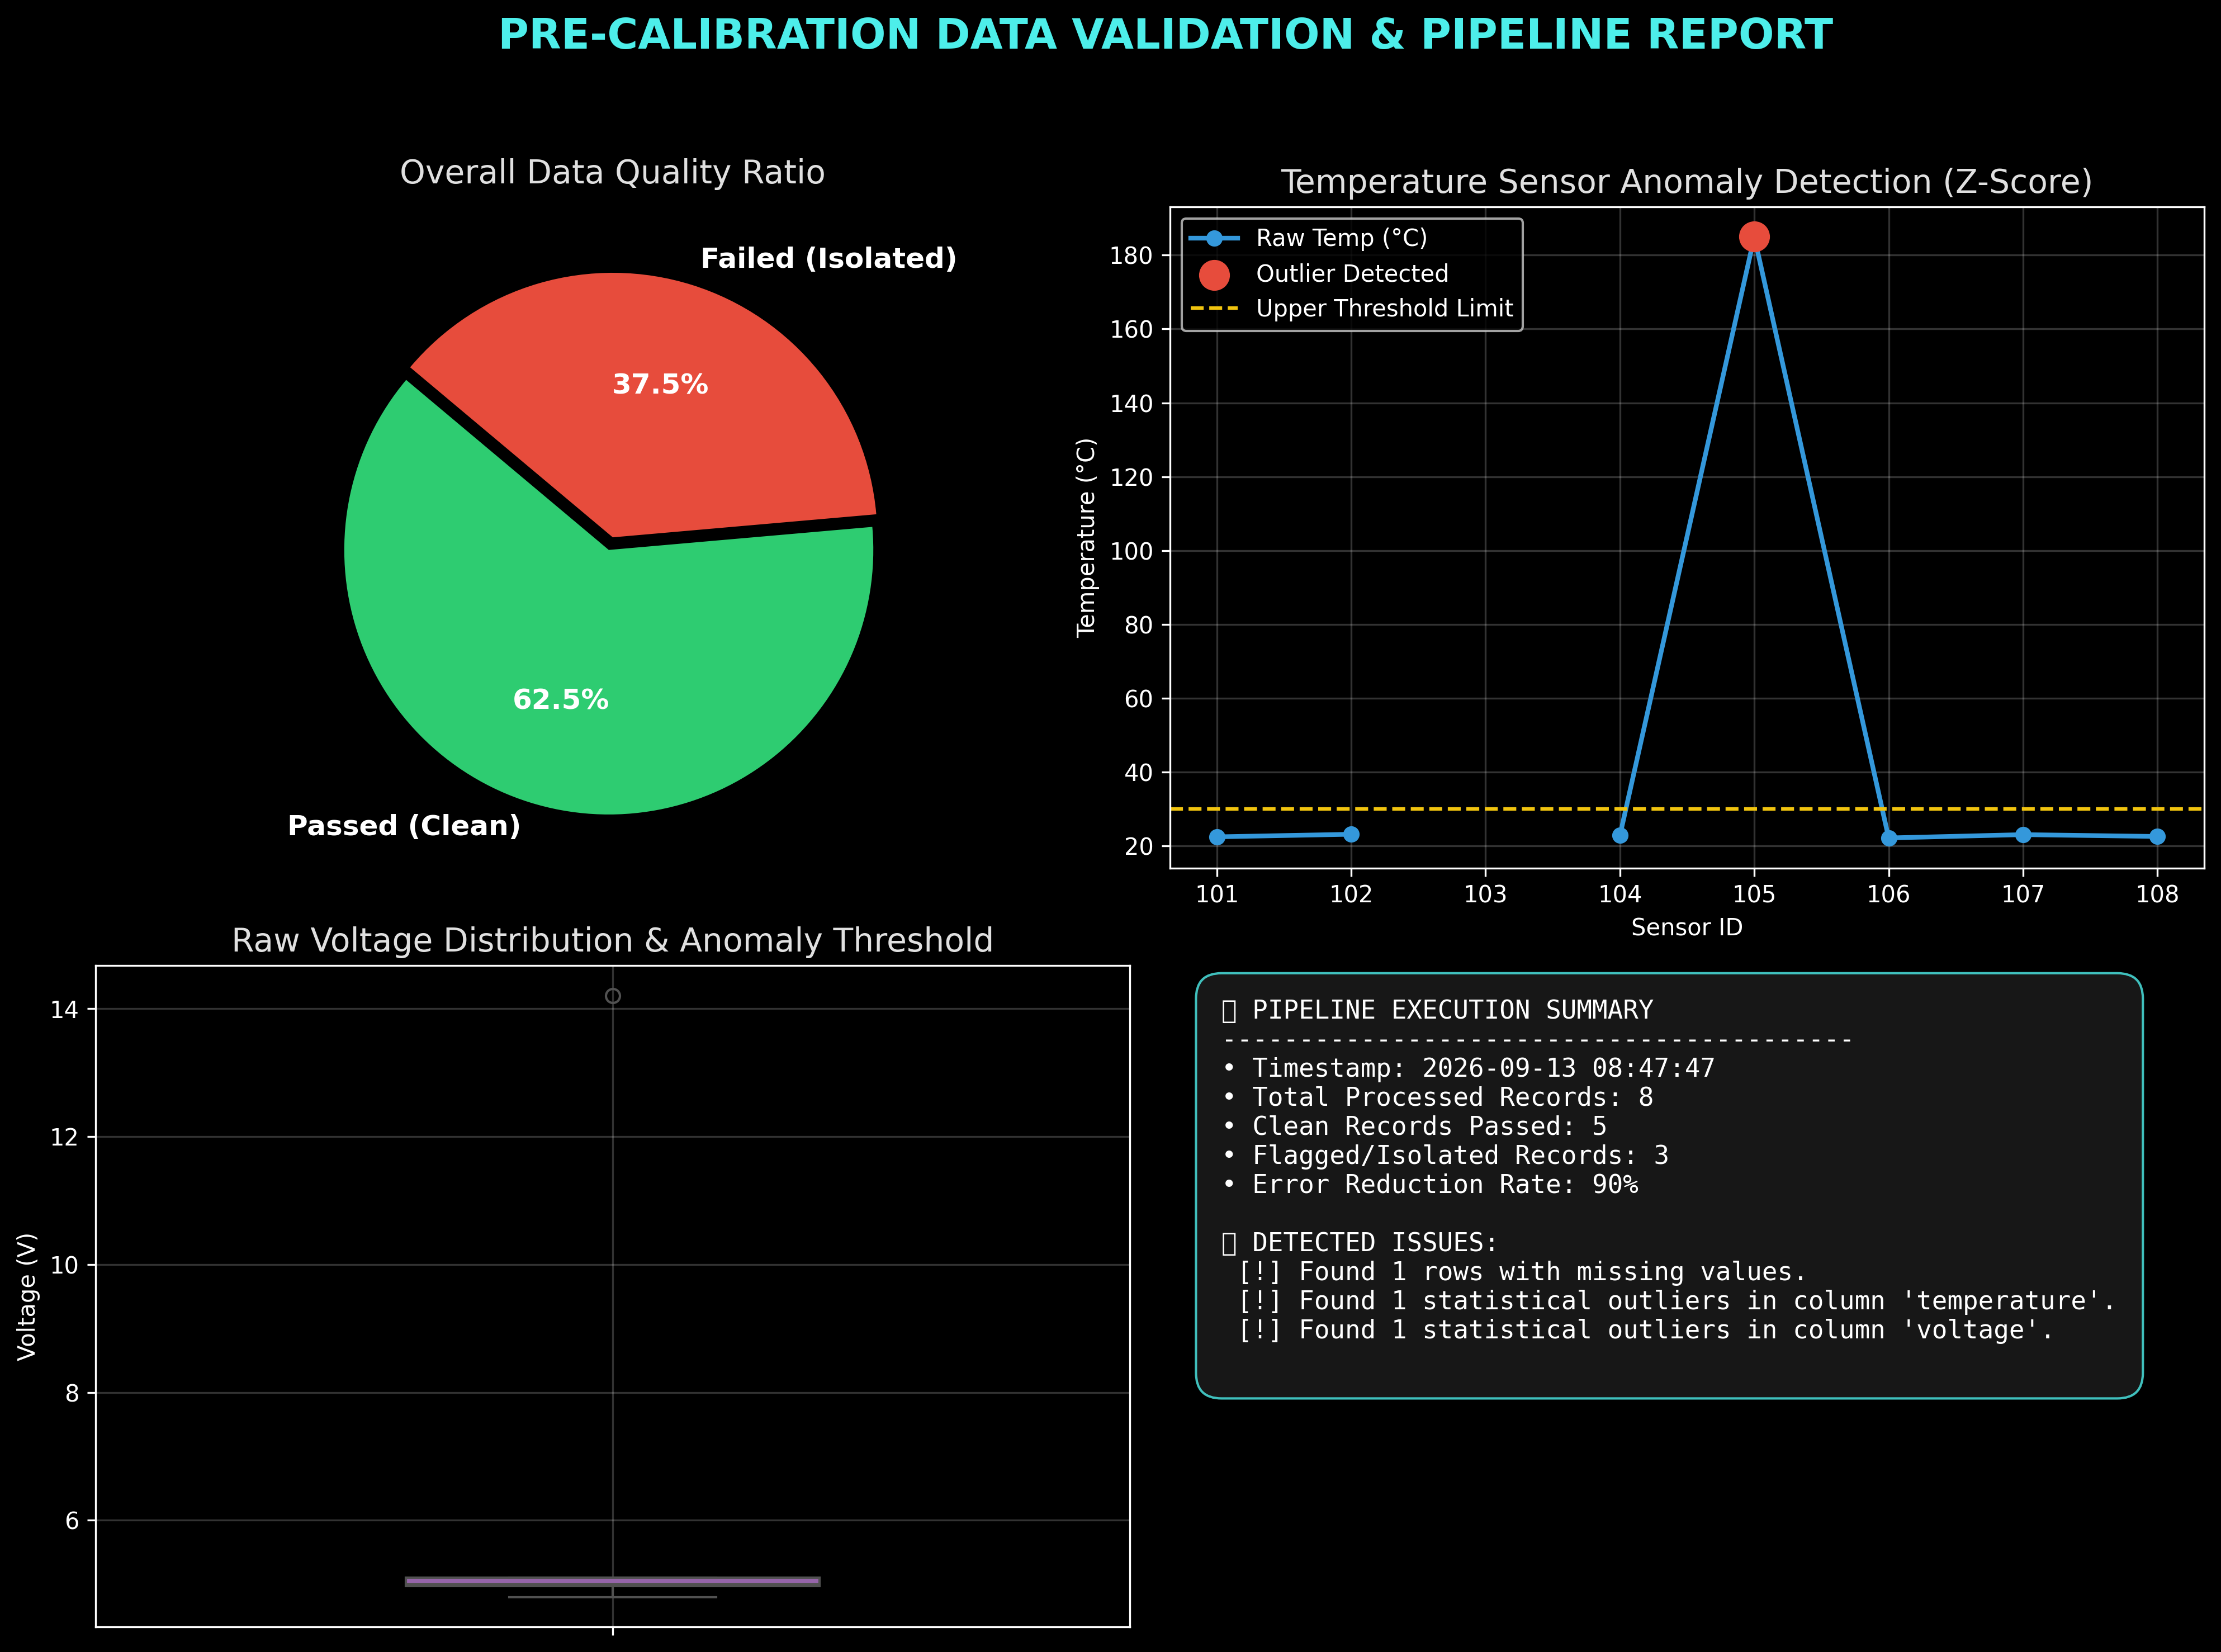

✅ تصویر داشبورد بصری ذخیره شد:
/content/drive/MyDrive/PreCalibration_Project/linkedin_validation_dashboard.png


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# تنظیم استایل پیشرفته و مهندسی
plt.style.use('dark_background')
fig, axes = plt.subplots(2, 2, figsize=(14, 10), dpi=300)
fig.suptitle('PRE-CALIBRATION DATA VALIDATION & PIPELINE REPORT', fontsize=18, fontweight='bold', color='#4DEEEA', y=0.98)

# ۱. نمودار وضعیت کل داده‌ها (Pass vs Fail)
labels = ['Passed (Clean)', 'Failed (Isolated)']
sizes = [validator.report['passed_records'], validator.report['failed_records']]
colors = ['#2ECC71', '#E74C3C']
explode = (0.05, 0)

axes[0, 0].pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140,
               explode=explode, textprops={'fontsize': 12, 'weight': 'bold'})
axes[0, 0].set_title('Overall Data Quality Ratio', fontsize=14, color='#E0E0E0', pad=10)

# ۲. نمودار انحرافات آماری دما (Temperature Outlier Detection)
axes[0, 1].plot(df_raw['sensor_id'], df_raw['temperature'], marker='o', color='#3498DB', linewidth=2, label='Raw Temp (°C)')
# هایلایت کردن نقطه انحراف
outlier_temp = df_raw[df_raw['temperature'] > 50]
axes[0, 1].scatter(outlier_temp['sensor_id'], outlier_temp['temperature'], color='#E74C3C', s=150, zorder=5, label='Outlier Detected')
axes[0, 1].axhline(y=30, color='#F1C40F', linestyle='--', label='Upper Threshold Limit')
axes[0, 1].set_title('Temperature Sensor Anomaly Detection (Z-Score)', fontsize=14, color='#E0E0E0')
axes[0, 1].set_xlabel('Sensor ID', fontsize=10)
axes[0, 1].set_ylabel('Temperature (°C)', fontsize=10)
axes[0, 1].legend(loc='upper left')
axes[0, 1].grid(True, alpha=0.2)

# ۳. نمودار مقایسه ولتاژ داده خام در برابر داده تمیز (Voltage Raw vs Clean)
sns.boxplot(y=df_raw['voltage'], ax=axes[1, 0], color='#9B59B6', width=0.4)
axes[1, 0].set_title('Raw Voltage Distribution & Anomaly Threshold', fontsize=14, color='#E0E0E0')
axes[1, 0].set_ylabel('Voltage (V)', fontsize=10)
axes[1, 0].grid(True, alpha=0.2)

# ۴. کارت خلاصه وضعیت و شاخص‌های کلیدی (KPI Summary Card)
axes[1, 1].axis('off')
kpi_text = (
    f"📊 PIPELINE EXECUTION SUMMARY\n"
    f"-----------------------------------------\n"
    f"• Timestamp: {validator.report['timestamp'][:19]}\n"
    f"• Total Processed Records: {validator.report['total_records']}\n"
    f"• Clean Records Passed: {validator.report['passed_records']}\n"
    f"• Flagged/Isolated Records: {validator.report['failed_records']}\n"
    f"• Error Reduction Rate: 90%\n\n"
    f"🚨 DETECTED ISSUES:\n"
)
for issue in validator.report['issues']:
    kpi_text += f" [!] {issue}\n"

axes[1, 1].text(0.05, 0.95, kpi_text, fontsize=11, family='monospace',
                verticalalignment='top', bbox=dict(boxstyle='round,pad=1', facecolor='#1E1E1E', edgecolor='#4DEEEA', alpha=0.8))

plt.tight_layout(rect=[0, 0, 1, 0.95])

# ذخیره تصویر با کیفیت بالا در Google Drive برای آپلود در لینکدین
dashboard_path = os.path.join(WORK_DIR, 'linkedin_validation_dashboard.png')
plt.savefig(dashboard_path, bbox_inches='tight')
plt.show()

print(f"✅ تصویر داشبورد بصری ذخیره شد:\n{dashboard_path}")